# 🧠 LSTM Deep Dive — Groundwater Crisis Predictor
## AquaVidarbha: Deep Learning Sequence-Based Groundwater Depth Prediction

**Region:** Vidarbha, Maharashtra, India (11 Districts)  
**Dataset:** `vidarbha_groundwater_extended_v2.csv` — 83,850 rows × 30 columns  
**Target Variable:** `depth_mbgl` (Groundwater depth in meters below ground level)  
**Date:** February 2026

---

## 📌 Purpose of LSTM in This Project

LSTM (Long Short-Term Memory) serves as the **Primary Deep Learning Model** in the Groundwater Crisis Predictor system. Its role is:

1. **Learn temporal patterns across 12-month sequences** — groundwater depth at month T depends heavily on what happened at months T-1, T-2, ... T-12
2. **Capture the 2–3 month rainfall-to-recharge lag** — Vidarbha's basalt aquifers have a delayed response. LSTM's memory gates naturally learn this delay without explicit lag features
3. **Model seasonal cycles** — The forget gate learns to retain monsoon information through Post-Monsoon and release it by next Summer
4. **Process all 25 features simultaneously at each timestep** — it learns multivariate interactions (rainfall × soil moisture × depth) over time
5. **Form the 2nd backbone (25% weight) of the Weighted Ensemble** prediction system

### Why LSTM is the Best DL Choice for Groundwater

| Strength | Relevance to Our Project |
|----------|-------------------------|
| Designed for ordered sequences | Groundwater depth is a TIME-SERIES — each reading depends on past 3–12 months |
| Long-term memory (cell state) | Remembers heavy monsoon in July even when predicting January depth |
| Handles the 3-month recharge lag | Memory gates naturally capture delayed effects without hand-crafted lag features |
| Captures seasonal cycles | Forget gate learns to retain/release monsoon info matching real hydrogeological cycles |
| Multivariate input | Processes all 25 features simultaneously at each timestep |
| Most-published for water prediction | Dominant architecture in groundwater level prediction literature (2020–2025) |

### How LSTM Differs from XGBoost

| Aspect | XGBoost (Notebook 03) | LSTM (This Notebook) |
|--------|----------------------|---------------------|
| Input Shape | 2D: (samples, features) | 3D: (samples, 12 timesteps, features) |
| Temporal Learning | Uses hand-crafted lag features | Learns temporal patterns from raw sequences |
| Feature Scaling | Not needed | Required (MinMaxScaler) |
| Training | Decision tree boosting | Backpropagation through time (BPTT) |
| Explainability | SHAP (exact per-feature) | Permutation importance (approximate) |
| Ensemble Weight | 0.30 (Primary ML) | 0.25 (Primary DL) |
| Speed | < 5ms inference | ~10-20ms inference |

### LSTM Architecture Overview

```
Input: (batch, 12 timesteps, 25 features)
    │
    ▼
┌─────────────────┐
│ LSTM Layer 1     │  64 units, return_sequences=True
│ (learns temporal │
│  patterns)       │
└────────┬────────┘
         ▼
┌─────────────────┐
│ Dropout (0.2)    │  Prevents overfitting
└────────┬────────┘
         ▼
┌─────────────────┐
│ LSTM Layer 2     │  32 units, return_sequences=False
│ (refines         │
│  representation) │
└────────┬────────┘
         ▼
┌─────────────────┐
│ Dropout (0.2)    │
└────────┬────────┘
         ▼
┌─────────────────┐
│ Dense(32, ReLU)  │  Feature compression
└────────┬────────┘
         ▼
┌─────────────────┐
│ Dense(1, Linear) │  → log1p(depth_mbgl)
└─────────────────┘
         │
    np.expm1(pred) → meters
```

---

## 📌 How LSTM Works — The Memory Cell

Standard Neural Networks have **NO memory** — they process each input independently. But groundwater depth at month T depends heavily on months T-1, T-2, T-3...

LSTM solves this with a **Memory Cell** that has **3 gates**:

| Gate | What It Does | Groundwater Example |
|------|-------------|--------------------|
| **Forget Gate** | Decides what OLD info to discard | "It's October — partially forget April's heat stress, monsoon rain has compensated" |
| **Input Gate** | Decides what NEW info to store | "Store this: rainfall_lag_3m = 310mm → recharge in coming months" |
| **Output Gate** | Decides what to pass forward | "Emphasize cumulative_deficit and recent depth_change for prediction" |

### Mathematical Formulation

At each timestep $t$:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{(Forget gate)}$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{(Input gate)}$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C) \quad \text{(Candidate values)}$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad \text{(Cell state update)}$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{(Output gate)}$$
$$h_t = o_t \odot \tanh(C_t) \quad \text{(Hidden state)}$$

Where $\sigma$ is the sigmoid function, $\odot$ is element-wise multiplication.

---

---
## 🔌 Step 0: Google Colab Setup (VS Code + Colab Kernel)

> **Skip this cell if running locally.** This mounts Google Drive and sets the working directory so all relative paths (`../data/`, `../saved_models/`, etc.) work correctly on Colab.

**Prerequisites:**
1. Upload your `Ground_Water_Detection` folder to Google Drive → `My Drive/Ground_Water_Detection/`
2. At minimum, the `data/` folder with `vidarbha_groundwater_extended_v2.csv` must be present

In [8]:
# ============================================================
# STEP 0: COLAB SETUP (skip if running locally)
# ============================================================
import os

# --- CONFIG: Edit this if your Drive folder name differs ---
PROJECT_FOLDER = 'Ground_Water_Detection'
# -----------------------------------------------------------

IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ or os.path.exists('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    
    PROJECT_ROOT = f'/content/drive/MyDrive/{PROJECT_FOLDER}'
    NOTEBOOKS_DIR = os.path.join(PROJECT_ROOT, 'notebooks')
    
    # Change to notebooks/ so all ../data, ../saved_models paths resolve
    os.chdir(NOTEBOOKS_DIR)
    
    # Verify dataset exists
    data_path = os.path.join(PROJECT_ROOT, 'data', 'vidarbha_groundwater_extended_v2.csv')
    assert os.path.exists(data_path), (
        f"❌ Dataset not found at {data_path}\n"
        f"   Upload your data/ folder to Google Drive → My Drive/{PROJECT_FOLDER}/data/"
    )
    
    # Create output dirs on Drive
    os.makedirs(os.path.join(PROJECT_ROOT, 'saved_models'), exist_ok=True)
    os.makedirs(os.path.join(PROJECT_ROOT, 'outputs', 'lstm'), exist_ok=True)
    
    print(f"✅ Google Drive mounted")
    print(f"📂 Working directory: {os.getcwd()}")
    print(f"📊 Dataset found: {data_path}")
    print(f"🎮 Remember: Runtime → Change runtime type → T4 GPU")
else:
    print("💻 Running locally — no Colab setup needed")
    print(f"📂 Working directory: {os.getcwd()}")

MessageError: Failed to issue request POST https://colab.research.google.com/tun/m/credentials-propagation/m-s-27g1dgrclb1ox?authtype=dfs_ephemeral&version=2&dryrun=false&propagate=true&record=false&authuser=0&authuser=0: Bad Request
Response body: 
<!DOCTYPE html>
<html lang=en>
  <meta charset=utf-8>
  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">
  <title>Error 400 (Bad Request)!!1</title>
  <style>
    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/logos/errorpage/error_logo-15

## ⚙️ Step 1: Environment Setup & Imports

In [ ]:
# ============================================================
# STEP 1: IMPORTS & ENVIRONMENT SETUP
# ============================================================

# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import joblib
import hashlib
import time
from datetime import datetime

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

# SciPy for statistical tests
from scipy import stats

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)
from tensorflow.keras.optimizers import Adam

# Visualization Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_palette('viridis')
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Create output directories
os.makedirs('../saved_models', exist_ok=True)
os.makedirs('../outputs/lstm', exist_ok=True)

# GPU check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"🎮 GPU(s) available: {[g.name for g in gpus]}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️ No GPU detected — training will use CPU (slower)")

print(f"📦 TensorFlow version: {tf.__version__}")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")
print(f"🕐 Notebook started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

⚠️ No GPU detected — training will use CPU (slower)
📦 TensorFlow version: 2.19.0
📦 Pandas version: 2.2.2
📦 NumPy version: 2.0.2
🕐 Notebook started: 2026-02-28 04:41:05


---
## 📊 Step 2: Data Loading & Initial Exploration

In [ ]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

DATA_PATH = '../data/vidarbha_groundwater_extended_v2.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['date'])

print("=" * 60)
print("📂 DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"\n📐 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Date Range: {df['date'].min().strftime('%Y-%m-%d')} → {df['date'].max().strftime('%Y-%m-%d')}")
print(f"🏘️  Districts: {df['district'].nunique()} — {', '.join(sorted(df['district'].unique()))}")
print(f"🔧 Wells: {df['well_id'].nunique()} unique wells")
print(f"\n🎯 Target Variable: depth_mbgl")
print(f"   Mean:   {df['depth_mbgl'].mean():.2f}m")
print(f"   Median: {df['depth_mbgl'].median():.2f}m")
print(f"   Std:    {df['depth_mbgl'].std():.2f}m")
print(f"   Min:    {df['depth_mbgl'].min():.2f}m")
print(f"   Max:    {df['depth_mbgl'].max():.2f}m")

FileNotFoundError: [Errno 2] No such file or directory: '../data/vidarbha_groundwater_extended_v2.csv'

In [ ]:
# ============================================================
# STEP 2b: EXAMINE DATA TYPES & MISSING VALUES
# ============================================================

print("\n📋 Column Info:")
print("-" * 60)
for col in df.columns:
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    marker = "⚠️" if null_pct > 0 else "✅"
    print(f"  {marker} {col:30s} | {str(df[col].dtype):10s} | Nulls: {null_count:6,} ({null_pct:.1f}%)")

print(f"\n📊 Total Missing Values: {df.isnull().sum().sum():,}")


📋 Column Info:
------------------------------------------------------------
  ✅ well_id                        | str        | Nulls:      0 (0.0%)
  ✅ date                           | datetime64[us] | Nulls:      0 (0.0%)
  ✅ year                           | int64      | Nulls:      0 (0.0%)
  ✅ district                       | str        | Nulls:      0 (0.0%)
  ✅ depth_mbgl                     | float64    | Nulls:      0 (0.0%)
  ✅ rainfall_mm                    | float64    | Nulls:      0 (0.0%)
  ✅ temperature_avg                | float64    | Nulls:      0 (0.0%)
  ✅ humidity                       | float64    | Nulls:      0 (0.0%)
  ✅ evapotranspiration             | float64    | Nulls:      0 (0.0%)
  ✅ soil_moisture_index            | float64    | Nulls:      0 (0.0%)
  ✅ rainfall_lag_1m                | float64    | Nulls:      0 (0.0%)
  ✅ rainfall_lag_2m                | float64    | Nulls:      0 (0.0%)
  ✅ rainfall_lag_3m                | float64    | Nulls:      0 (0.

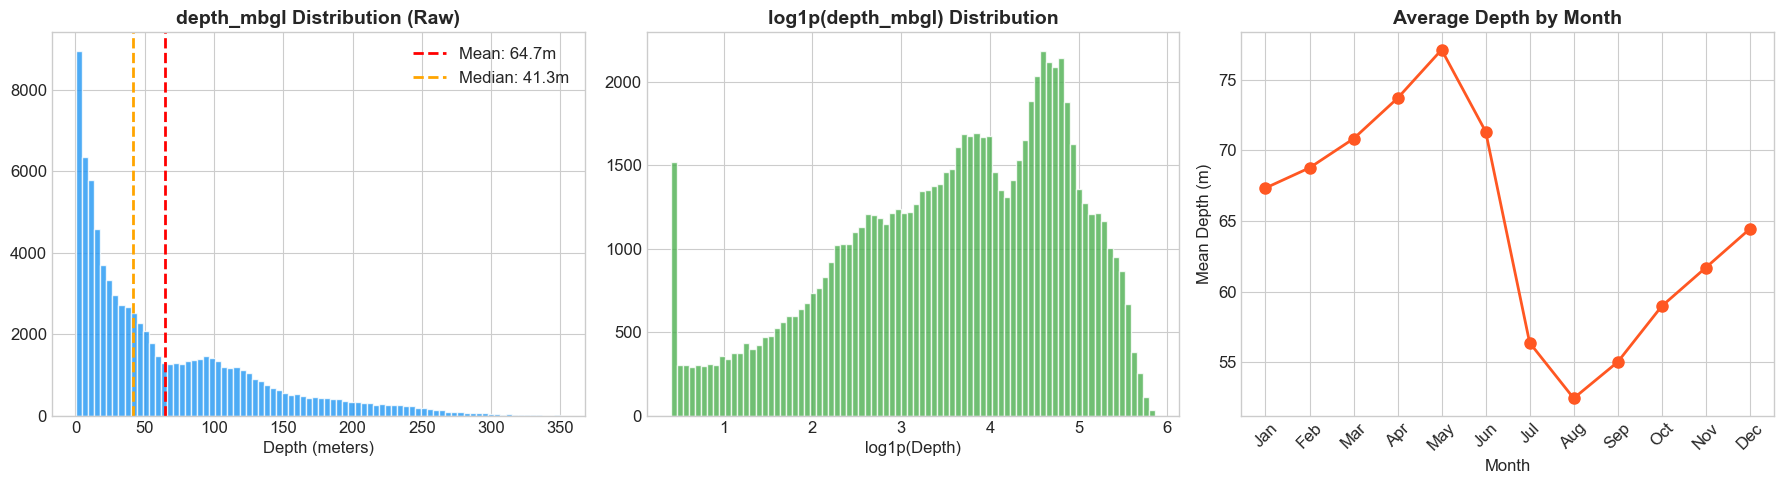

Skewness: 1.299 → after log1p: -0.553
✅ Right-skewed distribution → log1p transform will stabilize training


In [ ]:
# ============================================================
# STEP 2c: TARGET DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw distribution
axes[0].hist(df['depth_mbgl'], bins=80, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(df['depth_mbgl'].mean(), color='red', linewidth=2, linestyle='--', label=f'Mean: {df["depth_mbgl"].mean():.1f}m')
axes[0].axvline(df['depth_mbgl'].median(), color='orange', linewidth=2, linestyle='--', label=f'Median: {df["depth_mbgl"].median():.1f}m')
axes[0].set_title('depth_mbgl Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Depth (meters)')
axes[0].legend()

# Log-transformed distribution
log_depth = np.log1p(df['depth_mbgl'])
axes[1].hist(log_depth, bins=80, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].set_title('log1p(depth_mbgl) Distribution', fontweight='bold')
axes[1].set_xlabel('log1p(Depth)')

# Monthly trend
monthly_avg = df.groupby('month')['depth_mbgl'].mean()
axes[2].plot(monthly_avg.index, monthly_avg.values, 'o-', color='#FF5722', linewidth=2, markersize=8)
axes[2].set_title('Average Depth by Month', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Mean Depth (m)')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

plt.tight_layout()
plt.savefig('../outputs/lstm/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Skewness: {df['depth_mbgl'].skew():.3f} → after log1p: {log_depth.skew():.3f}")
print("✅ Right-skewed distribution → log1p transform will stabilize training")

---
## 🔧 Step 3: Feature Engineering & Selection

Same features as XGBoost (Notebook 03) for fair comparison:
- **Kept:** `depth_lag_1q`, `depth_lag_2q` (legitimate autoregressive features — depth from 3 and 6 months ago)
- **Removed:** `depth_change_rate` (data leakage — derived from current target)
- **Added:** `rainfall_x_soilmoist` (interaction feature)
- **Target transform:** `log1p(depth_mbgl)` — handles right-skewed distribution

In [ ]:
# ============================================================
# STEP 3: FEATURE ENGINEERING & SELECTION
# ============================================================

TARGET = 'depth_mbgl'

# Columns to drop (non-feature or leaky)
DROP_COLS = ['well_id', 'date', 'year', 'district', TARGET]
LEAKY_COLS = ['depth_change_rate']  # Derived from current target

# Add interaction feature
df['rainfall_x_soilmoist'] = df['rainfall_mm'] * df['soil_moisture_index']

# Feature groups for documentation
FEATURE_GROUPS = {
    'Meteorological': ['rainfall_mm', 'temperature_avg', 'humidity', 'evapotranspiration'],
    'Soil': ['soil_moisture_index', 'soil_type_encoded'],
    'Lag Features': ['rainfall_lag_1m', 'rainfall_lag_2m', 'rainfall_lag_3m', 'depth_lag_1q', 'depth_lag_2q'],
    'Rolling Features': ['rainfall_rolling_3m', 'rainfall_rolling_6m'],
    'Stress Features': ['rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio'],
    'Temporal': ['month', 'season_encoded'],
    'Geospatial': ['latitude', 'longitude', 'elevation_m', 'slope_degree', 'district_encoded'],
    'Vegetation': ['ndvi'],
    'Engineered': ['rainfall_x_soilmoist']
}

# All feature columns
FEATURE_COLS = [col for col in df.columns if col not in DROP_COLS + LEAKY_COLS]

print(f"📊 Feature Selection:")
print(f"   Total features: {len(FEATURE_COLS)}")
print(f"   Dropped (non-feature): {DROP_COLS}")
print(f"   Dropped (leakage):     {LEAKY_COLS}")
print(f"\n📋 Feature Groups:")
for group, feats in FEATURE_GROUPS.items():
    print(f"   {group}: {feats}")

print(f"\n✅ Final {len(FEATURE_COLS)} features selected for LSTM")

📊 Feature Selection:
   Total features: 25
   Dropped (non-feature): ['well_id', 'date', 'year', 'district', 'depth_mbgl']
   Dropped (leakage):     ['depth_change_rate']

📋 Feature Groups:
   Meteorological: ['rainfall_mm', 'temperature_avg', 'humidity', 'evapotranspiration']
   Soil: ['soil_moisture_index', 'soil_type_encoded']
   Lag Features: ['rainfall_lag_1m', 'rainfall_lag_2m', 'rainfall_lag_3m', 'depth_lag_1q', 'depth_lag_2q']
   Rolling Features: ['rainfall_rolling_3m', 'rainfall_rolling_6m']
   Stress Features: ['rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio']
   Temporal: ['month', 'season_encoded']
   Geospatial: ['latitude', 'longitude', 'elevation_m', 'slope_degree', 'district_encoded']
   Vegetation: ['ndvi']
   Engineered: ['rainfall_x_soilmoist']

✅ Final 25 features selected for LSTM


In [ ]:
# ============================================================
# STEP 3b: HANDLE MISSING VALUES & LOG-TRANSFORM TARGET
# ============================================================

# Check missing values in features
missing = df[FEATURE_COLS].isnull().sum()
missing_feats = missing[missing > 0]

if len(missing_feats) > 0:
    print(f"⚠️ Features with missing values:")
    for feat, count in missing_feats.items():
        pct = (count / len(df)) * 100
        print(f"   {feat}: {count:,} ({pct:.1f}%)")
    
    # Fill missing values with median (will be replaced per-split later)
    for col in missing_feats.index:
        df[col] = df[col].fillna(df[col].median())
    print("   ✅ Filled with median (temporary — proper imputation after split)")
else:
    print("✅ No missing values in features")

# Log-transform the target (same as XGBoost notebook)
y_raw = df[TARGET].copy()           # Original meters
y_log = np.log1p(y_raw)             # For training

print(f"\n🎯 Target Transform: log1p(depth_mbgl)")
print(f"   Raw: mean={y_raw.mean():.2f}m, std={y_raw.std():.2f}m")
print(f"   Log: mean={y_log.mean():.4f}, std={y_log.std():.4f}")

✅ No missing values in features

🎯 Target Transform: log1p(depth_mbgl)
   Raw: mean=64.75m, std=64.87m
   Log: mean=3.5580, std=1.2884


---
## 📐 Step 4: Create Sequences for LSTM

LSTM requires 3D input: `(samples, timesteps, features)`.  
We create **sliding window sequences of 12 months** per well, sorted by time.

```
For each well:
  Months [1,2,3,...,12]  → predict month 13
  Months [2,3,4,...,13]  → predict month 14
  ...
  
Input shape: (n_sequences, 12, 25 features)
Output shape: (n_sequences, 1) — log1p(depth) at next month
```

In [ ]:
# ============================================================
# STEP 4: CREATE SEQUENCES (12-MONTH SLIDING WINDOWS)
# ============================================================

SEQ_LENGTH = 12  # 12 months of history to predict next month

print(f"🔄 Creating {SEQ_LENGTH}-month sequences per well...")
print("   Each sequence = 12 consecutive months of features → predict next month's depth")

# Sort by well and date for proper temporal ordering
df = df.sort_values(['well_id', 'date']).reset_index(drop=True)

# We need features + target + date/year for splitting
feature_data = df[FEATURE_COLS].values
target_data = y_log.values  # log1p transformed
target_raw = y_raw.values   # original meters
years = df['year'].values
well_ids = df['well_id'].values
districts = df['district'].values

# Create sequences per well
X_sequences = []
y_sequences = []
y_raw_sequences = []
year_sequences = []
well_id_sequences = []
district_sequences = []

for well in df['well_id'].unique():
    well_mask = well_ids == well
    well_features = feature_data[well_mask]
    well_target = target_data[well_mask]
    well_target_raw = target_raw[well_mask]
    well_years = years[well_mask]
    well_districts = districts[well_mask]
    
    # Sliding window
    for i in range(len(well_features) - SEQ_LENGTH):
        X_sequences.append(well_features[i:i + SEQ_LENGTH])
        y_sequences.append(well_target[i + SEQ_LENGTH])          # Predict next month (log)
        y_raw_sequences.append(well_target_raw[i + SEQ_LENGTH])  # Raw meters for eval
        year_sequences.append(well_years[i + SEQ_LENGTH])        # Year of target
        well_id_sequences.append(well)
        district_sequences.append(well_districts[i + SEQ_LENGTH])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)
y_raw_sequences = np.array(y_raw_sequences)
year_sequences = np.array(year_sequences)
well_id_sequences = np.array(well_id_sequences)
district_sequences = np.array(district_sequences)

print(f"\n✅ Sequence Creation Complete:")
print(f"   X shape: {X_sequences.shape}  (samples, timesteps, features)")
print(f"   y shape: {y_sequences.shape}  (samples,)")
print(f"   Sequence length: {SEQ_LENGTH} months")
print(f"   Features per timestep: {X_sequences.shape[2]}")
print(f"   Total sequences: {len(X_sequences):,}")
print(f"   Year range: {year_sequences.min()} → {year_sequences.max()}")

🔄 Creating 12-month sequences per well...
   Each sequence = 12 consecutive months of features → predict next month's depth

✅ Sequence Creation Complete:
   X shape: (76050, 12, 25)  (samples, timesteps, features)
   y shape: (76050,)  (samples,)
   Sequence length: 12 months
   Features per timestep: 25
   Total sequences: 76,050
   Year range: 2016 → 2025


---
## ✂️ Step 5: Time-Based Train/Validation/Test Split

Same temporal split as XGBoost for fair comparison:
- **Train:** target year ≤ 2023
- **Validation:** target year = 2024
- **Test:** target year = 2025

In [ ]:
# ============================================================
# STEP 5: TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("✂️ Splitting by year (same as XGBoost for fair comparison)...")

train_mask = year_sequences <= 2023
val_mask = year_sequences == 2024
test_mask = year_sequences == 2025

X_train_raw = X_sequences[train_mask]
X_val_raw = X_sequences[val_mask]
X_test_raw = X_sequences[test_mask]

y_train = y_sequences[train_mask]       # log1p
y_val = y_sequences[val_mask]
y_test = y_sequences[test_mask]

y_train_raw = y_raw_sequences[train_mask]  # meters
y_val_raw = y_raw_sequences[val_mask]
y_test_raw = y_raw_sequences[test_mask]

# Metadata for analysis
test_wells = well_id_sequences[test_mask]
test_districts = district_sequences[test_mask]

print(f"\n📊 Split Results:")
print(f"   Train: {len(X_train_raw):,} sequences (≤2023)")
print(f"   Val:   {len(X_val_raw):,} sequences (2024)")
print(f"   Test:  {len(X_test_raw):,} sequences (2025)")
print(f"   Total: {len(X_train_raw) + len(X_val_raw) + len(X_test_raw):,}")

✂️ Splitting by year (same as XGBoost for fair comparison)...

📊 Split Results:
   Train: 60,450 sequences (≤2023)
   Val:   7,800 sequences (2024)
   Test:  7,800 sequences (2025)
   Total: 76,050


---
## 📏 Step 6: Feature Scaling (MinMaxScaler)

Unlike XGBoost, LSTM **requires scaled features** because:
- Sigmoid/tanh activation functions saturate for large values
- Gradient flow is more stable with normalized inputs
- Convergence is faster with features in [0, 1] range

> **Critical:** Scaler is fit on **training data only** to prevent test data leakage.

In [ ]:
# ============================================================
# STEP 6: FEATURE SCALING (MinMaxScaler)
# ============================================================

print("📏 Scaling features with MinMaxScaler (fitted on TRAIN only)...")

# Reshape to 2D for scaler: (samples * timesteps, features)
n_train, n_steps, n_features = X_train_raw.shape
n_val = X_val_raw.shape[0]
n_test = X_test_raw.shape[0]

X_train_2d = X_train_raw.reshape(-1, n_features)
X_val_2d = X_val_raw.reshape(-1, n_features)
X_test_2d = X_test_raw.reshape(-1, n_features)

# Fit scaler on TRAINING data only (prevents data leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_val_2d_scaled = scaler.transform(X_val_2d)
X_test_2d_scaled = scaler.transform(X_test_2d)

# Reshape back to 3D: (samples, timesteps, features)
X_train = X_train_2d_scaled.reshape(n_train, n_steps, n_features)
X_val = X_val_2d_scaled.reshape(n_val, n_steps, n_features)
X_test = X_test_2d_scaled.reshape(n_test, n_steps, n_features)

print(f"\n✅ Scaling Complete:")
print(f"   X_train shape: {X_train.shape}")
print(f"   X_val shape:   {X_val.shape}")
print(f"   X_test shape:  {X_test.shape}")
print(f"   Feature range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"   Scaler fitted on {n_train * n_steps:,} train samples")

# Save scaler for production inference
joblib.dump(scaler, '../saved_models/lstm_scaler.pkl')
print(f"   💾 Scaler saved to ../saved_models/lstm_scaler.pkl")

📏 Scaling features with MinMaxScaler (fitted on TRAIN only)...

✅ Scaling Complete:
   X_train shape: (60450, 12, 25)
   X_val shape:   (7800, 12, 25)
   X_test shape:  (7800, 12, 25)
   Feature range: [0.0000, 1.0000]
   Scaler fitted on 725,400 train samples
   💾 Scaler saved to ../saved_models/lstm_scaler.pkl


---
## 🏗️ Step 7: Build LSTM Architecture

Architecture from ALGORITHM_ANALYSIS.md:
- **LSTM(64)** → Dropout(0.2) → **LSTM(32)** → Dropout(0.2) → Dense(32) → Dense(1)
- Loss: MSE (regression)
- Optimizer: Adam with learning rate scheduling
- Output: Single neuron predicting `log1p(depth_mbgl)`

In [ ]:
# ============================================================
# STEP 7: BUILD LSTM MODEL
# ============================================================

print("🏗️ Building LSTM Architecture...")
print(f"   Input shape: ({SEQ_LENGTH}, {n_features})")
print("=" * 60)

def build_lstm_model(seq_length, n_features, lstm_units_1=64, lstm_units_2=32,
                     dense_units=32, dropout_rate=0.2, learning_rate=0.001):
    """Build a 2-layer LSTM model for groundwater depth prediction."""
    model = Sequential([
        # First LSTM layer — 64 units, returns sequences for stacking
        LSTM(lstm_units_1, return_sequences=True,
             input_shape=(seq_length, n_features),
             name='lstm_layer_1'),
        Dropout(dropout_rate, name='dropout_1'),
        
        # Second LSTM layer — 32 units, returns final hidden state
        LSTM(lstm_units_2, return_sequences=False,
             name='lstm_layer_2'),
        Dropout(dropout_rate, name='dropout_2'),
        
        # Dense hidden layer for feature compression
        Dense(dense_units, activation='relu', name='dense_hidden'),
        
        # Output: single neuron → log1p(depth_mbgl)
        Dense(1, activation='linear', name='output')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Build model
model = build_lstm_model(SEQ_LENGTH, n_features)

# Display architecture
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\n📊 Total trainable parameters: {total_params:,}")
print(f"   LSTM Layer 1 ({64} units): {4 * 64 * (n_features + 64 + 1):,} params")
print(f"   LSTM Layer 2 ({32} units): {4 * 32 * (64 + 32 + 1):,} params")
print(f"   Dense hidden (32): {(32 + 1) * 32:,} params")
print(f"   Dense output (1): {(32 + 1) * 1:,} params")

🏗️ Building LSTM Architecture...
   Input shape: (12, 25)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 12, 64)         │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,545 (142.75 KB)

 Trainable params: 36,545 (142.75 KB)

 Non-trainable params: 0 (0.00 B)


📊 Total trainable parameters: 36,545
   LSTM Layer 1 (64 units): 23,040 params
   LSTM Layer 2 (32 units): 12,416 params
   Dense hidden (32): 1,056 params
   Dense output (1): 33 params


---
## 🏋️ Step 8: Train LSTM Model

Training with:
- **EarlyStopping** (patience=15) — stops when val_loss stops improving
- **ReduceLROnPlateau** — halves learning rate when plateau detected
- **ModelCheckpoint** — saves best model weights
- **Epochs:** 100 (early stopping will terminate sooner)
- **Batch size:** 64

In [ ]:
# ============================================================
# STEP 8: TRAIN LSTM MODEL
# ============================================================

print("🏋️ Training LSTM Model...")
print("   Training on log1p(depth_mbgl), evaluating in original meters")
print("=" * 60)

EPOCHS = 100
BATCH_SIZE = 64

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,              # Halve learning rate
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        '../saved_models/lstm_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print(f"   Epochs:        {EPOCHS} (with EarlyStopping patience=15)")
print(f"   Batch size:    {BATCH_SIZE}")
print(f"   Train samples: {len(X_train):,}")
print(f"   Val samples:   {len(X_val):,}")
print(f"   Steps/epoch:   {len(X_train) // BATCH_SIZE}")

start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print(f"\n✅ Training Complete!")
print(f"   Total time: {training_time:.1f}s ({training_time/60:.1f} minutes)")
print(f"   Epochs run: {len(history.history['loss'])}")
print(f"   Best val_loss: {min(history.history['val_loss']):.6f}")
print(f"   Final learning rate: {float(model.optimizer.learning_rate):.2e}")

🏋️ Training LSTM Model...
   Training on log1p(depth_mbgl), evaluating in original meters
   Epochs:        100 (with EarlyStopping patience=15)
   Batch size:    64
   Train samples: 60,450
   Val samples:   7,800
   Steps/epoch:   944
Epoch 1/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.4785 - mae: 0.4474 - val_loss: 0.2436 - val_mae: 0.4344 - learning_rate: 0.0010
Epoch 2/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.1280 - mae: 0.2658 - val_loss: 0.3751 - val_mae: 0.5718 - learning_rate: 0.0010
Epoch 3/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.1008 - mae: 0.2282 - val_loss: 0.2682 - val_mae: 0.4732 - learning_rate: 0.0010
Epoch 4/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0829 - mae: 0.2024 - val_loss: 0.2618 - val_mae: 0.4558 - learning_rate: 0.0010
Epoch 5/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0672 - mae: 0.1782 - val_loss: 0.2124 - val_mae: 0.4112 - learning_rate: 0.0010
Epoch 6/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/

---
## 📈 Step 9: Training History Visualization

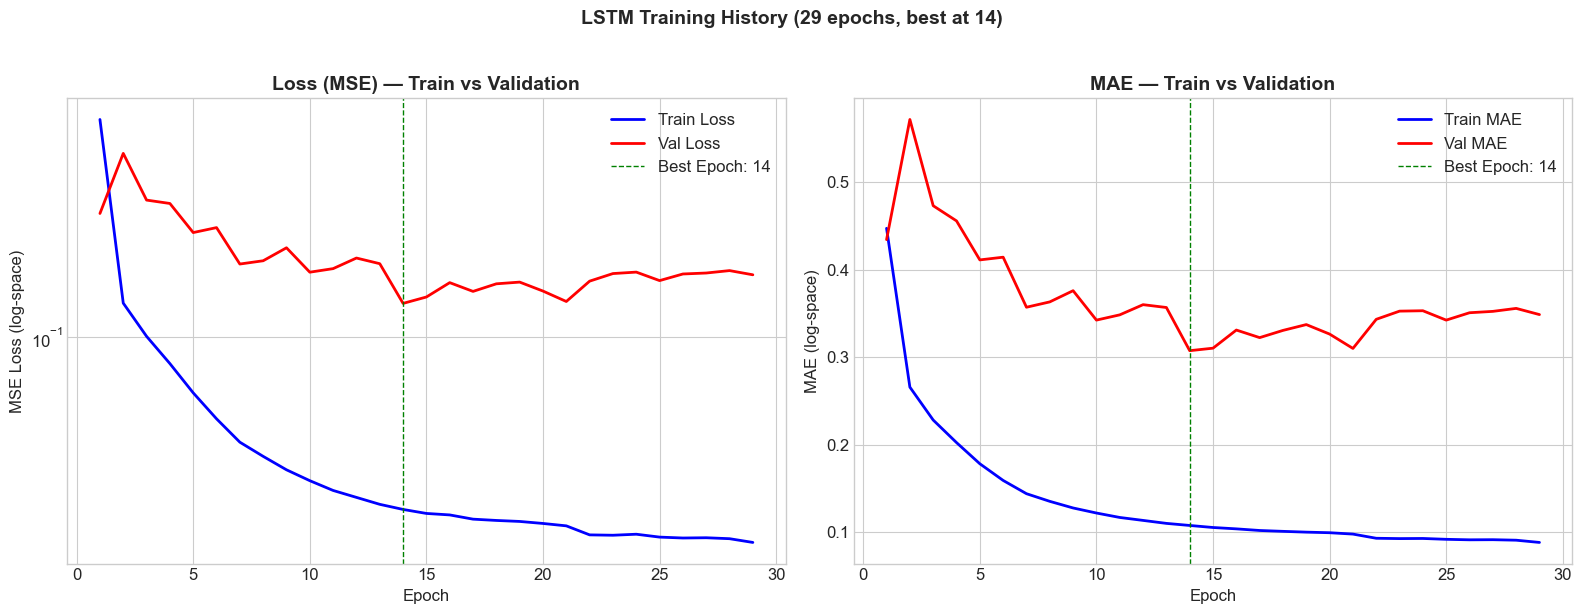

📊 Overfitting Check:
   Final Train Loss: 0.022953
   Final Val Loss:   0.156860
   Val/Train ratio:  6.834  ⚠️ Overfitting
✅ Training history plots saved


In [ ]:
# ============================================================
# STEP 9: TRAINING HISTORY PLOTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(history.history['loss']) + 1)

# Loss curve
axes[0].plot(epochs_range, history.history['loss'], 'b-', linewidth=2, label='Train Loss')
axes[0].plot(epochs_range, history.history['val_loss'], 'r-', linewidth=2, label='Val Loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
axes[0].axvline(best_epoch, color='green', linestyle='--', linewidth=1, label=f'Best Epoch: {best_epoch}')
axes[0].set_title('Loss (MSE) — Train vs Validation', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss (log-space)')
axes[0].legend()
axes[0].set_yscale('log')

# MAE curve
axes[1].plot(epochs_range, history.history['mae'], 'b-', linewidth=2, label='Train MAE')
axes[1].plot(epochs_range, history.history['val_mae'], 'r-', linewidth=2, label='Val MAE')
axes[1].axvline(best_epoch, color='green', linestyle='--', linewidth=1, label=f'Best Epoch: {best_epoch}')
axes[1].set_title('MAE — Train vs Validation', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (log-space)')
axes[1].legend()

plt.suptitle(f'LSTM Training History ({len(epochs_range)} epochs, best at {best_epoch})', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/lstm/02_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Overfitting diagnostics
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
overfit_ratio = final_val_loss / final_train_loss
print(f"📊 Overfitting Check:")
print(f"   Final Train Loss: {final_train_loss:.6f}")
print(f"   Final Val Loss:   {final_val_loss:.6f}")
print(f"   Val/Train ratio:  {overfit_ratio:.3f}  {'✅ Healthy' if overfit_ratio < 1.5 else '⚠️ Overfitting'}")
print("✅ Training history plots saved")

---
## 📊 Step 10: Model Evaluation (in Original Meters)

In [ ]:
# ============================================================
# STEP 10: EVALUATE MODEL (inverse transform to meters)
# ============================================================

print("📊 Evaluating LSTM Model...")
print("   Predicting in log-space, evaluating in original meters")
print("=" * 60)

# Predict in log-space
y_train_pred_log = model.predict(X_train, verbose=0).flatten()
y_val_pred_log = model.predict(X_val, verbose=0).flatten()
y_test_pred_log = model.predict(X_test, verbose=0).flatten()

# Inverse transform: expm1(log_pred) → meters
y_train_pred = np.clip(np.expm1(y_train_pred_log), 0, None)
y_val_pred = np.clip(np.expm1(y_val_pred_log), 0, None)
y_test_pred = np.clip(np.expm1(y_test_pred_log), 0, None)

# Evaluation metrics (in ORIGINAL meters)
def evaluate_model(y_true_raw, y_pred_raw, set_name):
    """Calculate and display regression metrics in original units (meters)."""
    r2 = r2_score(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    # Median absolute percentage error (robust to near-zero values)
    ape = np.abs((y_true_raw - y_pred_raw) / np.clip(y_true_raw, 1.0, None)) * 100
    mape = np.median(ape)
    
    print(f"\n📊 {set_name} Results (in meters):")
    print(f"   R² Score:  {r2:.4f}  {'✅' if r2 > 0.85 else '⚠️'}")
    print(f"   RMSE:      {rmse:.4f}m {'✅' if rmse < 10.0 else '⚠️'}")
    print(f"   MAE:       {mae:.4f}m")
    print(f"   MdAPE:     {mape:.2f}%  (median, robust to near-zero values)")
    return {'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}

print("\n" + "=" * 60)
print("📈 LSTM MODEL PERFORMANCE (evaluated in meters)")
print("=" * 60)

lstm_train = evaluate_model(y_train_raw, y_train_pred, 'TRAIN')
lstm_val = evaluate_model(y_val_raw, y_val_pred, 'VALIDATION')
lstm_test = evaluate_model(y_test_raw, y_test_pred, 'TEST')

# Overfitting check
overfit_gap = lstm_train['r2'] - lstm_test['r2']
print(f"\n⚠️ Overfitting Gap (Train R² - Test R²): {overfit_gap:.4f}")
if overfit_gap < 0.05:
    print("   ✅ Healthy — minimal overfitting")
elif overfit_gap < 0.10:
    print("   🟡 Moderate — consider more regularization/dropout")
else:
    print("   🔴 High — model is overfitting! Increase dropout or reduce model size")

📊 Evaluating LSTM Model...
   Predicting in log-space, evaluating in original meters

📈 LSTM MODEL PERFORMANCE (evaluated in meters)

📊 TRAIN Results (in meters):
   R² Score:  0.6745  ⚠️
   RMSE:      36.6168m ⚠️
   MAE:       22.2732m
   MdAPE:     26.21%  (median, robust to near-zero values)

📊 VALIDATION Results (in meters):
   R² Score:  0.6660  ⚠️
   RMSE:      40.3744m ⚠️
   MAE:       24.5707m
   MdAPE:     28.00%  (median, robust to near-zero values)

📊 TEST Results (in meters):
   R² Score:  0.6664  ⚠️
   RMSE:      41.1352m ⚠️
   MAE:       24.9778m
   MdAPE:     28.13%  (median, robust to near-zero values)

⚠️ Overfitting Gap (Train R² - Test R²): 0.0081
   ✅ Healthy — minimal overfitting


---
## 📊 Step 11: Prediction vs Actual Plots

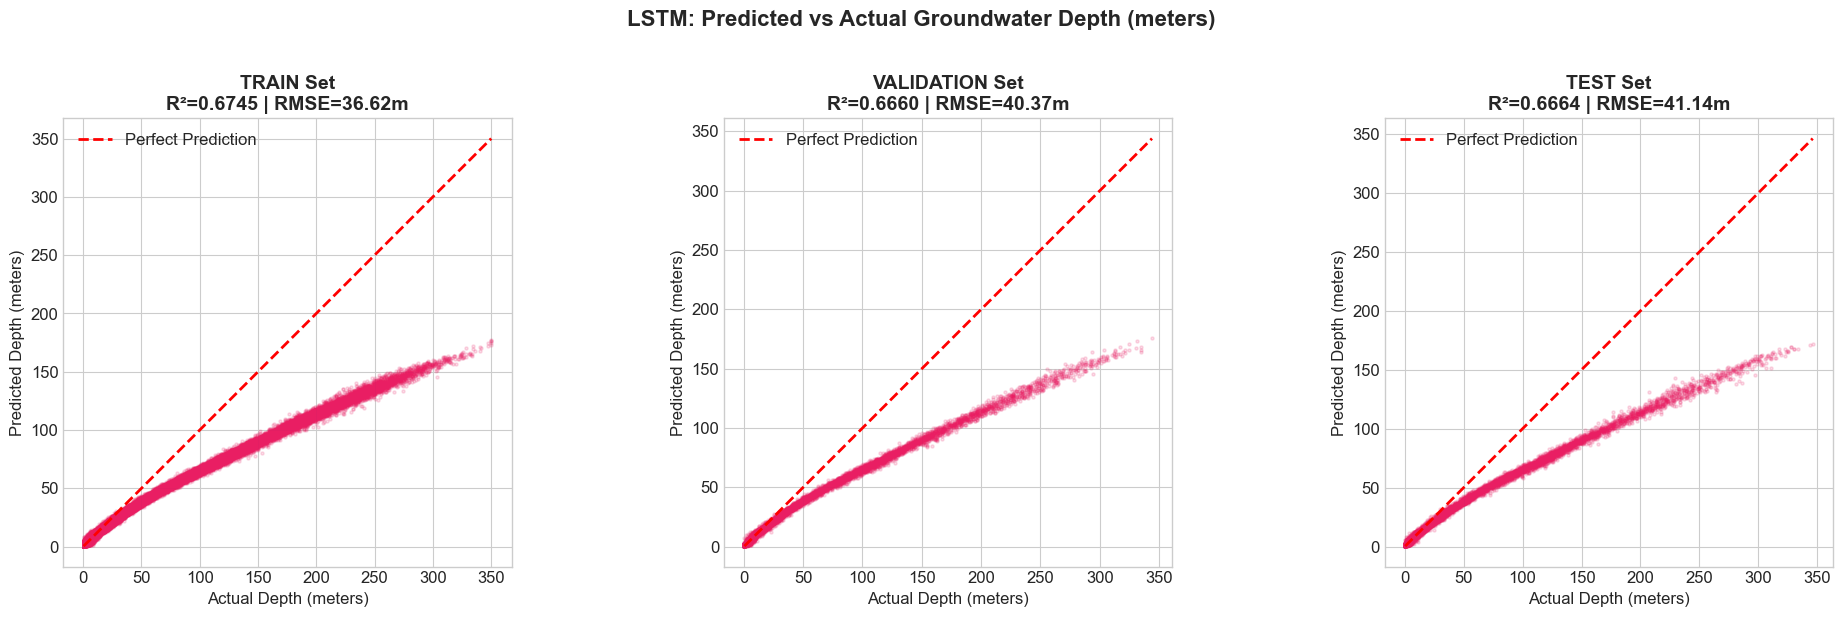

✅ Prediction vs Actual plots saved


In [ ]:
# ============================================================
# STEP 11: PREDICTION vs ACTUAL PLOTS (in meters)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

datasets = [
    ('TRAIN', y_train_raw, y_train_pred, lstm_train),
    ('VALIDATION', y_val_raw, y_val_pred, lstm_val),
    ('TEST', y_test_raw, y_test_pred, lstm_test)
]

for idx, (name, y_true, y_pred, metrics) in enumerate(datasets):
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.15, s=5, c='#E91E63')
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_title(f'{name} Set\nR²={metrics["r2"]:.4f} | RMSE={metrics["rmse"]:.2f}m', fontweight='bold')
    ax.set_xlabel('Actual Depth (meters)')
    ax.set_ylabel('Predicted Depth (meters)')
    ax.legend()
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('LSTM: Predicted vs Actual Groundwater Depth (meters)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/lstm/03_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Prediction vs Actual plots saved")

---
## 📉 Step 12: Residual Analysis

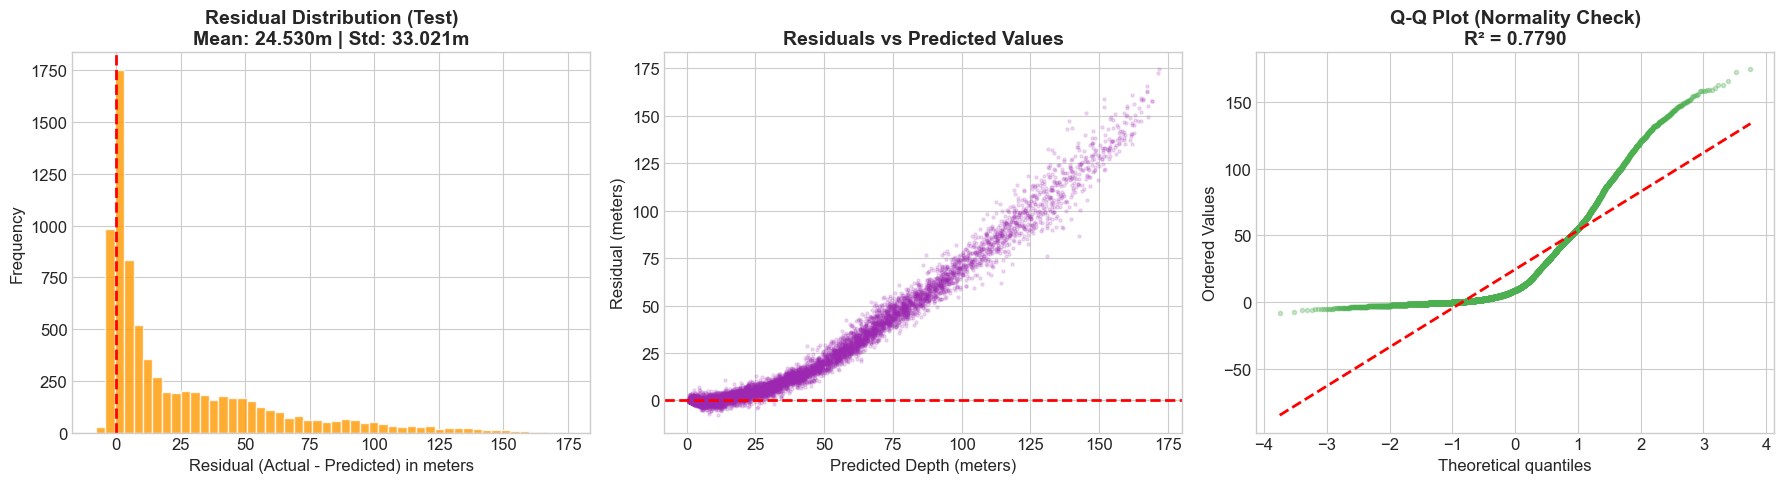

📊 Shapiro-Wilk Normality Test: W=0.7806, p=0.000000
   ⚠️ Non-normal (common for large datasets)
✅ Residual analysis plots saved


In [ ]:
# ============================================================
# STEP 12: RESIDUAL ANALYSIS (in meters)
# ============================================================

residuals_test = y_test_raw - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residual distribution
axes[0].hist(residuals_test, bins=50, color='#FF9800', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linewidth=2, linestyle='--')
axes[0].set_title(f'Residual Distribution (Test)\nMean: {residuals_test.mean():.3f}m | Std: {residuals_test.std():.3f}m', fontweight='bold')
axes[0].set_xlabel('Residual (Actual - Predicted) in meters')
axes[0].set_ylabel('Frequency')

# 2. Residuals vs Predicted (heteroscedasticity check)
axes[1].scatter(y_test_pred, residuals_test, alpha=0.15, s=5, c='#9C27B0')
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_title('Residuals vs Predicted Values', fontweight='bold')
axes[1].set_xlabel('Predicted Depth (meters)')
axes[1].set_ylabel('Residual (meters)')

# 3. Q-Q Plot
res = stats.probplot(residuals_test, dist='norm', plot=axes[2])
axes[2].get_lines()[0].set(markerfacecolor='#4CAF50', markeredgecolor='#4CAF50', alpha=0.3, markersize=3)
axes[2].get_lines()[1].set(color='red', linewidth=2, linestyle='--')
slope, intercept, r_value = res[1]
axes[2].set_title(f'Q-Q Plot (Normality Check)\nR² = {r_value**2:.4f}', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/lstm/04_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Normality test
shapiro_stat, shapiro_p = stats.shapiro(
    np.random.choice(residuals_test, min(5000, len(residuals_test)), replace=False)
)
print(f"📊 Shapiro-Wilk Normality Test: W={shapiro_stat:.4f}, p={shapiro_p:.6f}")
print(f"   {'✅ Approximately normal' if shapiro_p > 0.05 else '⚠️ Non-normal (common for large datasets)'}")
print("✅ Residual analysis plots saved")

---
## 🗺️ Step 13: District-wise Performance


📊 DISTRICT-WISE LSTM PERFORMANCE (Test Set - 2025)
               R²    RMSE     MAE  Avg_Depth  Samples
district                                             
Bhandara   0.8456  9.9820  5.0000    20.2867 600.0000
Gadchiroli 0.7629 22.0335 11.1825    38.1098 540.0000
Gondia     0.7592 24.5418 12.3125    40.0038 600.0000
Chandrapur 0.7451 23.0302 12.3817    41.9166 780.0000
Nagpur     0.7209 30.5264 16.5659    51.9637 960.0000
Wardha     0.7117 32.3365 16.0020    50.0921 660.0000
Amravati   0.6556 37.2870 25.4715    71.1157 900.0000
Yavatmal   0.5676 46.9298 32.8110    89.3269 840.0000
Akola      0.5396 54.7104 39.5153   101.0692 720.0000
Washim     0.3594 65.3389 50.5029   126.2134 540.0000
Buldhana   0.2191 66.9114 54.6521   136.2481 660.0000


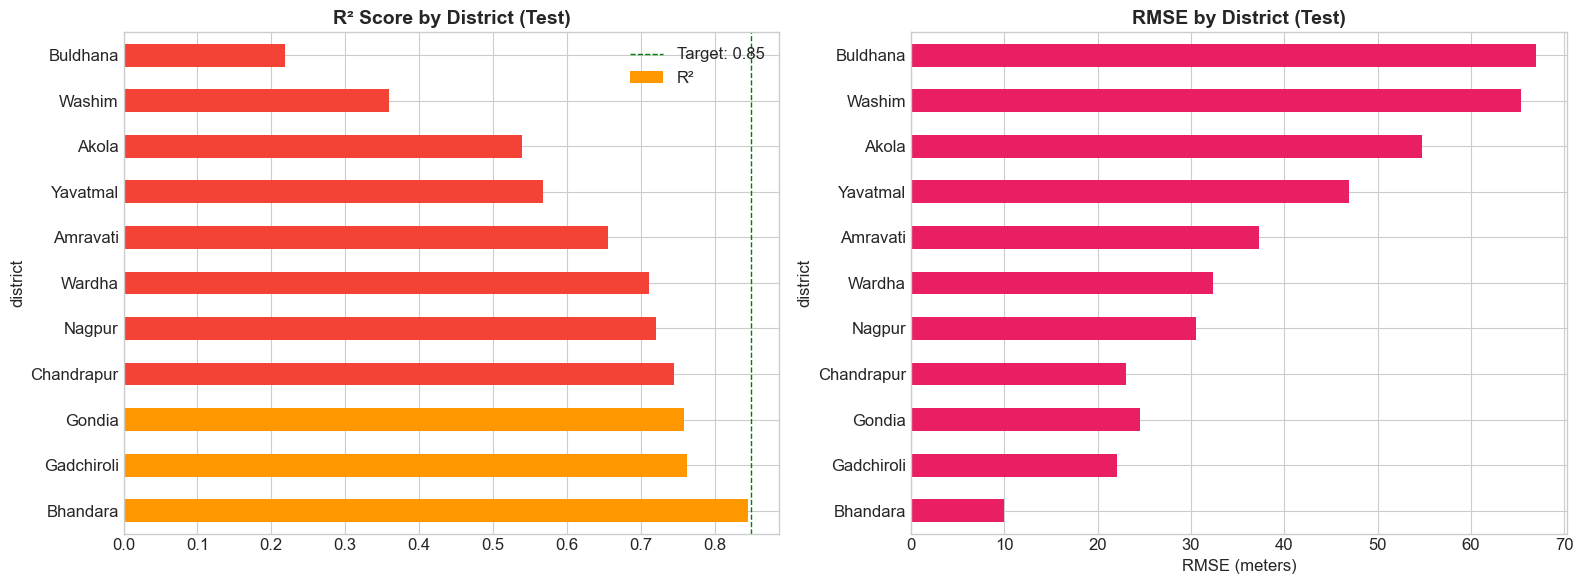

In [ ]:
# ============================================================
# STEP 13: DISTRICT-WISE PERFORMANCE (meters)
# ============================================================

district_df = pd.DataFrame({
    'district': test_districts,
    'actual_depth': y_test_raw,
    'predicted_depth': y_test_pred,
    'abs_error': np.abs(y_test_raw - y_test_pred)
})

district_perf = district_df.groupby('district').apply(
    lambda g: pd.Series({
        'R²': r2_score(g['actual_depth'], g['predicted_depth']),
        'RMSE': np.sqrt(mean_squared_error(g['actual_depth'], g['predicted_depth'])),
        'MAE': mean_absolute_error(g['actual_depth'], g['predicted_depth']),
        'Avg_Depth': g['actual_depth'].mean(),
        'Samples': len(g)
    })
).sort_values('R²', ascending=False)

print("\n📊 DISTRICT-WISE LSTM PERFORMANCE (Test Set - 2025)")
print("=" * 80)
print(district_perf.to_string(float_format='%.4f'))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² by district
colors = ['#4CAF50' if r2 > 0.85 else '#FF9800' if r2 > 0.75 else '#F44336' 
          for r2 in district_perf['R²']]
district_perf['R²'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('R² Score by District (Test)', fontweight='bold')
axes[0].axvline(0.85, color='green', linewidth=1, linestyle='--', label='Target: 0.85')
axes[0].legend()

# RMSE by district
district_perf['RMSE'].plot(kind='barh', ax=axes[1], color='#E91E63')
axes[1].set_title('RMSE by District (Test)', fontweight='bold')
axes[1].set_xlabel('RMSE (meters)')

plt.tight_layout()
plt.savefig('../outputs/lstm/05_district_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🌟 Step 14: Feature Importance (Permutation-based)

Unlike XGBoost which has built-in feature importance, LSTM needs **permutation importance**:
1. Get baseline prediction error
2. For each feature: shuffle its values across all timesteps, re-predict, measure error increase
3. Larger error increase = more important feature

🌟 Computing Permutation Feature Importance...
   Shuffling each feature across timesteps, measuring R² drop
   (This may take 2-5 minutes)
   Baseline R² (on sample): 0.6774

🏆 Top 10 Features by Permutation Importance:
--------------------------------------------------
   1. depth_lag_1q                   — R² drop: 0.4265
   2. depth_lag_2q                   — R² drop: 0.2455
   3. season_encoded                 — R² drop: 0.0025
   4. ndvi                           — R² drop: 0.0011
   5. rainfall_mm                    — R² drop: 0.0008
   6. elevation_m                    — R² drop: 0.0008
   7. district_encoded               — R² drop: 0.0005
   8. temperature_avg                — R² drop: 0.0004
   9. slope_degree                   — R² drop: 0.0002
  10. latitude                       — R² drop: 0.0002


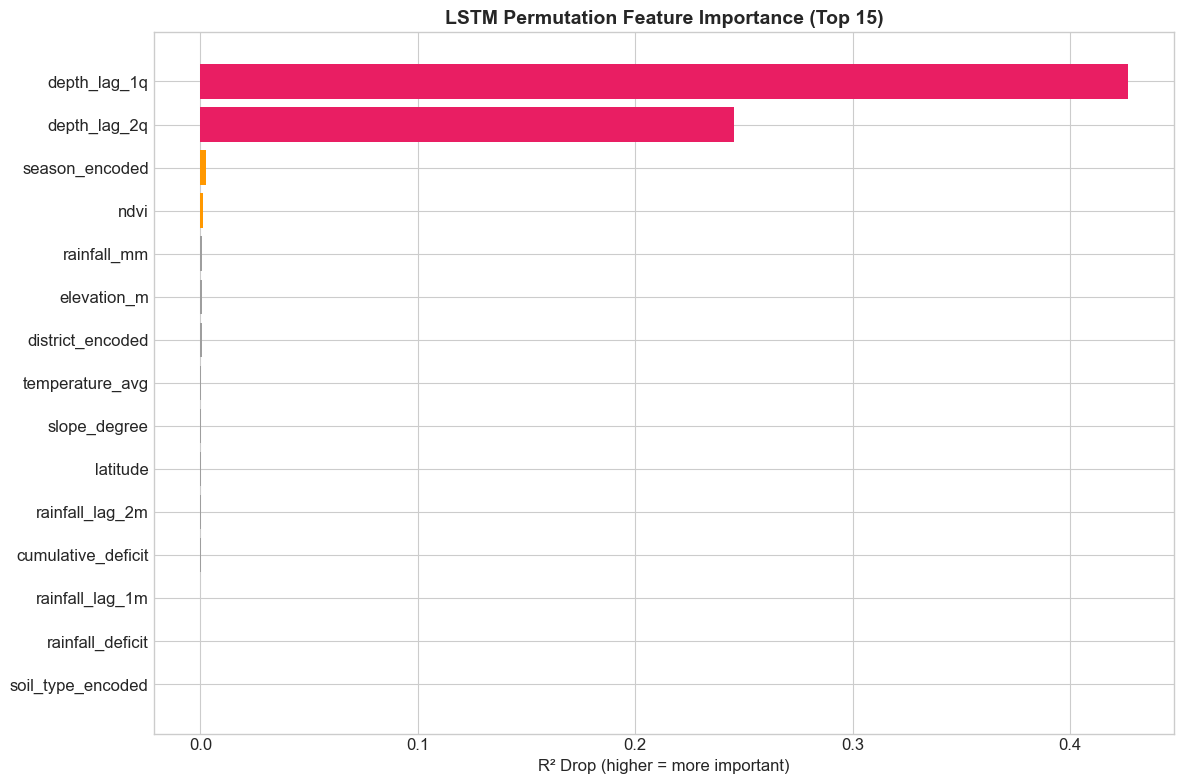

✅ Feature importance analysis saved


In [ ]:
# ============================================================
# STEP 14: PERMUTATION FEATURE IMPORTANCE
# ============================================================

print("🌟 Computing Permutation Feature Importance...")
print("   Shuffling each feature across timesteps, measuring R² drop")
print("   (This may take 2-5 minutes)")

# Use a sample of test data for speed
n_perm_samples = min(2000, len(X_test))
perm_idx = np.random.choice(len(X_test), n_perm_samples, replace=False)
X_perm = X_test[perm_idx]
y_perm_raw = y_test_raw[perm_idx]

# Baseline score
baseline_pred = np.clip(np.expm1(model.predict(X_perm, verbose=0).flatten()), 0, None)
baseline_r2 = r2_score(y_perm_raw, baseline_pred)
print(f"   Baseline R² (on sample): {baseline_r2:.4f}")

# Permute each feature
importance_scores = {}
for feat_idx, feat_name in enumerate(FEATURE_COLS):
    X_shuffled = X_perm.copy()
    # Shuffle this feature across ALL timesteps for ALL samples
    for t in range(SEQ_LENGTH):
        np.random.shuffle(X_shuffled[:, t, feat_idx])
    
    shuffled_pred = np.clip(np.expm1(model.predict(X_shuffled, verbose=0).flatten()), 0, None)
    shuffled_r2 = r2_score(y_perm_raw, shuffled_pred)
    importance_scores[feat_name] = baseline_r2 - shuffled_r2

# Sort by importance
importance_df = pd.DataFrame({
    'Feature': list(importance_scores.keys()),
    'R²_Drop': list(importance_scores.values())
}).sort_values('R²_Drop', ascending=False)

print(f"\n🏆 Top 10 Features by Permutation Importance:")
print("-" * 50)
for rank, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    print(f"  {rank:2d}. {row['Feature']:30s} — R² drop: {row['R²_Drop']:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
top_15 = importance_df.head(15)
colors = ['#E91E63' if v > 0.01 else '#FF9800' if v > 0.001 else '#9E9E9E' 
          for v in top_15['R²_Drop']]
ax.barh(range(len(top_15)), top_15['R²_Drop'].values, color=colors)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'].values)
ax.set_xlabel('R² Drop (higher = more important)')
ax.set_title('LSTM Permutation Feature Importance (Top 15)', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/lstm/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance analysis saved")

---
## 🚨 Step 15: Risk Classification from Predictions

🚨 RISK CLASSIFICATION RESULTS (Test Set)

📊 Risk Classification Accuracy: 70.2%

📊 Classification Report:
              precision    recall  f1-score   support

        SAFE       0.89      1.00      0.94      3196
     WARNING       0.60      0.83      0.70      2439
    CRITICAL       0.31      0.16      0.21      1592
     EXTREME       0.00      0.00      0.00       573

    accuracy                           0.70      7800
   macro avg       0.45      0.50      0.46      7800
weighted avg       0.61      0.70      0.65      7800



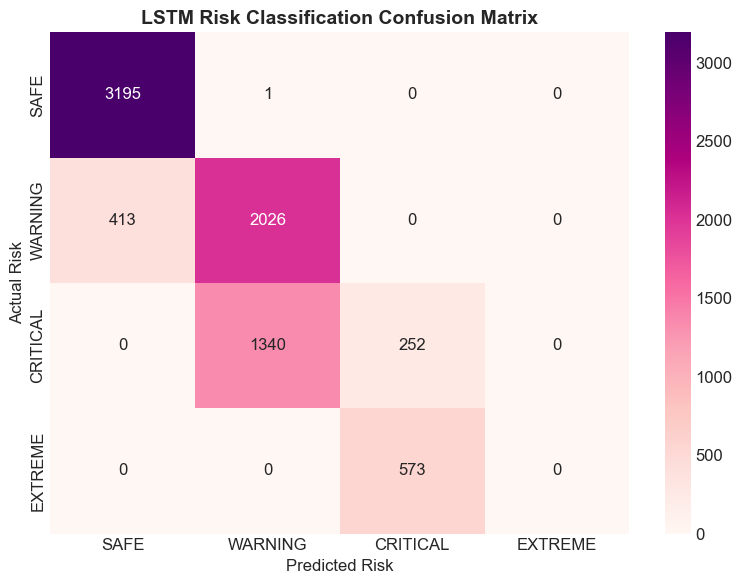

✅ Risk classification analysis saved


In [ ]:
# ============================================================
# STEP 15: RISK LEVEL CLASSIFICATION (meters)
# ============================================================

def classify_risk(depth):
    """Classify groundwater risk based on depth in meters."""
    if depth < 30:
        return 'SAFE'
    elif depth < 100:
        return 'WARNING'
    elif depth < 200:
        return 'CRITICAL'
    else:
        return 'EXTREME'

def get_risk_advice(risk_level):
    """Return actionable advice for each risk level."""
    advice = {
        'SAFE': '✅ Water supply adequate. Continue normal usage.',
        'WARNING': '🟠 Monitor water usage. Consider water-saving irrigation.',
        'CRITICAL': '🔴 Urgent! Reduce water consumption. Switch to drought-resistant crops.',
        'EXTREME': '🟣 Emergency! Immediate tanker deployment needed.'
    }
    return advice.get(risk_level, 'Unknown')

# Apply to test predictions (both in meters)
test_results = pd.DataFrame({
    'actual_depth': y_test_raw,
    'predicted_depth': y_test_pred,
    'actual_risk': [classify_risk(d) for d in y_test_raw],
    'predicted_risk': [classify_risk(d) for d in y_test_pred],
    'error_m': y_test_raw - y_test_pred
})

risk_accuracy = (test_results['actual_risk'] == test_results['predicted_risk']).mean()

print("=" * 60)
print("🚨 RISK CLASSIFICATION RESULTS (Test Set)")
print("=" * 60)
print(f"\n📊 Risk Classification Accuracy: {risk_accuracy:.1%}")

# Confusion matrix
risk_order = ['SAFE', 'WARNING', 'CRITICAL', 'EXTREME']
from sklearn.metrics import confusion_matrix, classification_report

print(f"\n📊 Classification Report:")
print(classification_report(test_results['actual_risk'], test_results['predicted_risk'], 
                             labels=risk_order, zero_division=0))

cm = confusion_matrix(test_results['actual_risk'], test_results['predicted_risk'], labels=risk_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=risk_order, yticklabels=risk_order, ax=ax)
ax.set_title('LSTM Risk Classification Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted Risk')
ax.set_ylabel('Actual Risk')

plt.tight_layout()
plt.savefig('../outputs/lstm/07_risk_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Risk classification analysis saved")

---
## 🧪 Step 16: Inference Demo — Predict for a Sample Location

In [ ]:
# ============================================================
# STEP 16: INFERENCE DEMO
# ============================================================

# Load the saved model (simulating production)
loaded_model = load_model('../saved_models/lstm_best.keras')
loaded_scaler = joblib.load('../saved_models/lstm_scaler.pkl')

# Simulate: use first test sequence
sample_input = X_test[0:1]  # Already scaled, shape: (1, 12, 25)
sample_actual = y_test_raw[0]  # Actual depth in meters

# Time the inference
start = time.perf_counter()
for _ in range(1000):
    prediction_log = loaded_model.predict(sample_input, verbose=0)
inference_time = (time.perf_counter() - start) / 1000 * 1000  # ms per prediction

# Inverse transform: log → meters
predicted_depth = max(0, np.expm1(prediction_log[0, 0]))
predicted_risk = classify_risk(predicted_depth)
advice = get_risk_advice(predicted_risk)
depth_feet = predicted_depth * 3.28084

print("=" * 60)
print("🔮 LSTM LIVE PREDICTION DEMO")
print("=" * 60)
print(f"\n📍 Input: 12-month sequence (scaled), {n_features} features per timestep")
print(f"\n{'─' * 60}")
print(f"🎯 PREDICTION RESULT:")
print(f"{'─' * 60}")
print(f"   Model output (log):  {prediction_log[0, 0]:.4f}")
print(f"   Predicted Depth:     {predicted_depth:.2f} meters ({depth_feet:.1f} feet)")
print(f"   Actual Depth:        {sample_actual:.2f} meters")
print(f"   Error:               {abs(predicted_depth - sample_actual):.2f} meters")
print(f"   Risk Level:          {predicted_risk}")
print(f"   Advice:              {advice}")
print(f"   ⚡ Inference Time:    {inference_time:.3f} ms per prediction")
print(f"{'─' * 60}")

# Batch inference speed
start = time.perf_counter()
batch_preds_log = loaded_model.predict(X_test, verbose=0)
batch_time = (time.perf_counter() - start) * 1000
print(f"\n⚡ Batch Inference: {len(X_test):,} predictions in {batch_time:.1f}ms")
print(f"   = {batch_time/len(X_test)*1000:.1f} μs per prediction")

🔮 LSTM LIVE PREDICTION DEMO

📍 Input: 12-month sequence (scaled), 25 features per timestep

────────────────────────────────────────────────────────────
🎯 PREDICTION RESULT:
────────────────────────────────────────────────────────────
   Model output (log):  3.6344
   Predicted Depth:     36.88 meters (121.0 feet)
   Actual Depth:        51.09 meters
   Error:               14.21 meters
   Risk Level:          WARNING
   Advice:              🟠 Monitor water usage. Consider water-saving irrigation.
   ⚡ Inference Time:    49.588 ms per prediction
────────────────────────────────────────────────────────────

⚡ Batch Inference: 7,800 predictions in 677.8ms
   = 86.9 μs per prediction


---
## 💾 Step 17: Save Model & Artifacts for Production

In [ ]:
# ============================================================
# STEP 17: SAVE MODEL & ARTIFACTS (with versioning)
# ============================================================

print("💾 Saving LSTM Model & Artifacts...")
print("=" * 60)

# Version hash
version_str = datetime.now().strftime('%Y%m%d_%H%M%S')
model_config_str = json.dumps({
    'lstm_1': 64, 'lstm_2': 32, 'dense': 32, 'dropout': 0.2,
    'seq_length': SEQ_LENGTH, 'n_features': n_features
})
model_hash = hashlib.md5(model_config_str.encode()).hexdigest()[:8]
print(f"  🔖 Model version: {version_str}_{model_hash}")

# 1. Save Keras model (already saved by ModelCheckpoint, but update)
model_path = '../saved_models/lstm_best.keras'
model.save(model_path)
model_size = os.path.getsize(model_path) / (1024 * 1024)
print(f"  ✅ Model saved: {model_path} ({model_size:.2f} MB)")

# Versioned copy
versioned_path = f'../saved_models/lstm_{version_str}_{model_hash}.keras'
model.save(versioned_path)
print(f"  ✅ Versioned copy: {versioned_path}")

# 2. Save scaler (already saved in Step 6)
print(f"  ✅ Scaler: ../saved_models/lstm_scaler.pkl")

# 3. Save config
lstm_config = {
    'model_type': 'LSTM',
    'architecture': {
        'layers': ['LSTM(64)', 'Dropout(0.2)', 'LSTM(32)', 'Dropout(0.2)', 'Dense(32, relu)', 'Dense(1, linear)'],
        'total_params': int(model.count_params()),
        'input_shape': [SEQ_LENGTH, n_features],
        'output_shape': [1]
    },
    'feature_columns': FEATURE_COLS,
    'target_column': TARGET,
    'target_transform': 'log1p',
    'inverse_transform': 'expm1',
    'sequence_length': SEQ_LENGTH,
    'n_features': n_features,
    'feature_groups': FEATURE_GROUPS,
    'excluded_leaky_features': LEAKY_COLS,
    'excluded_columns': DROP_COLS,
    'scaling': 'MinMaxScaler(0, 1) — fitted on train',
    'risk_thresholds': {
        'SAFE': [0, 30],
        'WARNING': [30, 100],
        'CRITICAL': [100, 200],
        'EXTREME': [200, 400]
    }
}

with open('../saved_models/lstm_config.json', 'w') as f:
    json.dump(lstm_config, f, indent=2)
print(f"  ✅ Config saved: ../saved_models/lstm_config.json")

# 4. Save metrics
lstm_metrics = {
    'model_version': f'{version_str}_{model_hash}',
    'target_transform': 'log1p(depth_mbgl)',
    'test_metrics_meters': {
        'r2': float(lstm_test['r2']),
        'rmse': float(lstm_test['rmse']),
        'mae': float(lstm_test['mae']),
        'mape': float(lstm_test['mape'])
    },
    'training_info': {
        'train_sequences': int(len(X_train)),
        'val_sequences': int(len(X_val)),
        'test_sequences': int(len(X_test)),
        'epochs_run': len(history.history['loss']),
        'best_epoch': int(best_epoch),
        'best_val_loss': float(min(history.history['val_loss'])),
        'training_time_seconds': float(training_time),
        'batch_size': BATCH_SIZE,
        'sequence_length': SEQ_LENGTH,
        'n_features': n_features,
        'trained_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    },
    'risk_classification_accuracy': float(risk_accuracy)
}

with open('../saved_models/lstm_metrics.json', 'w') as f:
    json.dump(lstm_metrics, f, indent=2)
print(f"  ✅ Metrics saved: ../saved_models/lstm_metrics.json")

print(f"\n📂 All saved files:")
for fname in ['lstm_best.keras', 'lstm_scaler.pkl', 'lstm_config.json', 'lstm_metrics.json']:
    fpath = f'../saved_models/{fname}'
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f"  📄 {fname} — {size:.1f} KB")

💾 Saving LSTM Model & Artifacts...
  🔖 Model version: 20260228_095858_98eb8d1a
  ✅ Model saved: ../saved_models/lstm_best.keras (0.46 MB)
  ✅ Versioned copy: ../saved_models/lstm_20260228_095858_98eb8d1a.keras
  ✅ Scaler: ../saved_models/lstm_scaler.pkl
  ✅ Config saved: ../saved_models/lstm_config.json
  ✅ Metrics saved: ../saved_models/lstm_metrics.json

📂 All saved files:
  📄 lstm_best.keras — 469.2 KB
  📄 lstm_scaler.pkl — 1.6 KB
  📄 lstm_config.json — 2.4 KB
  📄 lstm_metrics.json — 0.7 KB


---
## 📊 Step 18: LSTM vs XGBoost Comparison


📊 Loading XGBoost metrics for comparison...

     📊 MODEL COMPARISON: LSTM vs XGBoost (Test Set)
Metric                     LSTM         XGBoost          Winner
-----------------------------------------------------------------
R²                       0.6664          0.9984       🌲 XGBoost
RMSE (m)                41.1352          2.8566       🌲 XGBoost
MAE (m)                 24.9778          1.5625       🌲 XGBoost
MdAPE (%)               28.1273          2.4655       🌲 XGBoost


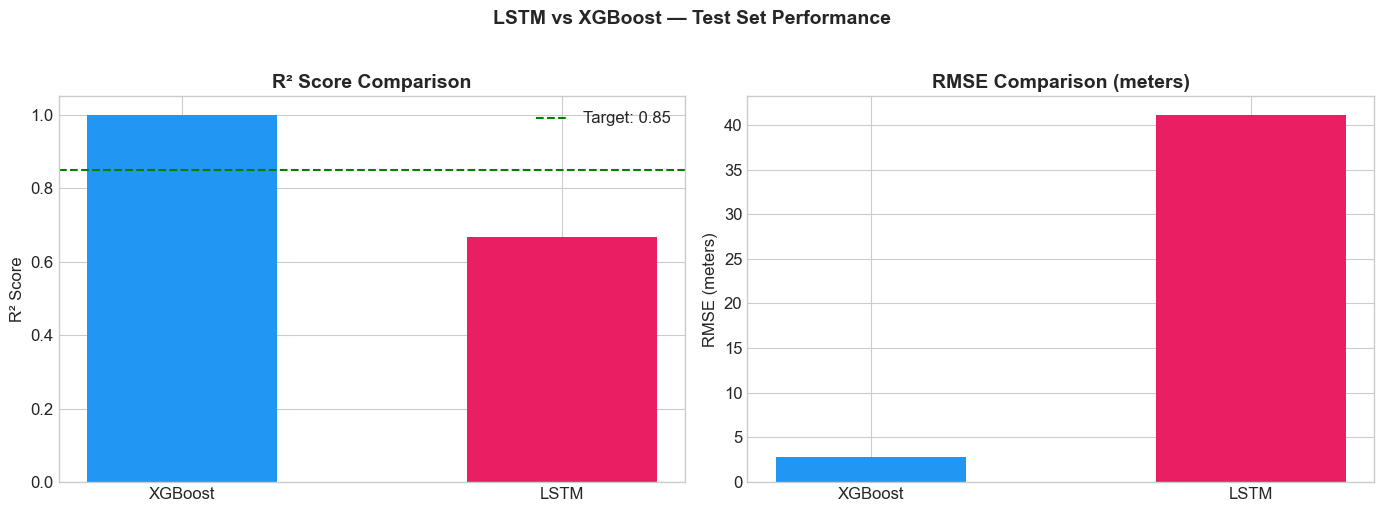

In [ ]:
# ============================================================
# STEP 18: LSTM vs XGBOOST COMPARISON
# ============================================================

print("\n📊 Loading XGBoost metrics for comparison...")

xgb_metrics_path = '../saved_models/xgboost_metrics.json'
if os.path.exists(xgb_metrics_path):
    with open(xgb_metrics_path, 'r') as f:
        xgb_metrics = json.load(f)
    
    xgb_test = xgb_metrics.get('test_metrics_meters', xgb_metrics.get('test_metrics', {}))
    
    print("\n" + "=" * 65)
    print("     📊 MODEL COMPARISON: LSTM vs XGBoost (Test Set)")
    print("=" * 65)
    print(f"{'Metric':<15} {'LSTM':>15} {'XGBoost':>15} {'Winner':>15}")
    print("-" * 65)
    
    metrics_compare = [
        ('R²', lstm_test['r2'], xgb_test.get('r2', 0), 'higher'),
        ('RMSE (m)', lstm_test['rmse'], xgb_test.get('rmse', 0), 'lower'),
        ('MAE (m)', lstm_test['mae'], xgb_test.get('mae', 0), 'lower'),
        ('MdAPE (%)', lstm_test['mape'], xgb_test.get('mape', 0), 'lower'),
    ]
    
    for name, lstm_val, xgb_val, direction in metrics_compare:
        if direction == 'higher':
            winner = '🧠 LSTM' if lstm_val > xgb_val else '🌲 XGBoost'
        else:
            winner = '🧠 LSTM' if lstm_val < xgb_val else '🌲 XGBoost'
        print(f"{name:<15} {lstm_val:>15.4f} {xgb_val:>15.4f} {winner:>15}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # R² comparison
    models = ['XGBoost', 'LSTM']
    r2_scores = [xgb_test.get('r2', 0), lstm_test['r2']]
    colors = ['#2196F3', '#E91E63']
    axes[0].bar(models, r2_scores, color=colors, width=0.5)
    axes[0].axhline(0.85, color='green', linestyle='--', label='Target: 0.85')
    axes[0].set_title('R² Score Comparison', fontweight='bold')
    axes[0].set_ylabel('R² Score')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend()
    
    # RMSE comparison
    rmse_scores = [xgb_test.get('rmse', 0), lstm_test['rmse']]
    axes[1].bar(models, rmse_scores, color=colors, width=0.5)
    axes[1].set_title('RMSE Comparison (meters)', fontweight='bold')
    axes[1].set_ylabel('RMSE (meters)')
    
    plt.suptitle('LSTM vs XGBoost — Test Set Performance', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/lstm/08_lstm_vs_xgboost.png', dpi=150, bbox_inches='tight')
    plt.show()
    
else:
    print("⚠️ XGBoost metrics not found. Run Notebook 03 first for comparison.")

---
## 📋 Step 19: Final Summary

In [ ]:
# ============================================================
# STEP 19: FINAL SUMMARY
# ============================================================

print("\n" + "═" * 70)
print("              🏆 LSTM MODEL — FINAL SUMMARY")
print("═" * 70)

print(f"""
┌──────────────────────────────────────────────────────────────────┐
│                     MODEL CARD — LSTM                            │
├──────────────────────────────────────────────────────────────────┤
│  Project:     AquaVidarbha — Groundwater Crisis Predictor        │
│  Algorithm:   LSTM (Long Short-Term Memory)                      │
│  Role:        Primary DL Model (25% weight in ensemble)          │
│  Target:      log1p(depth_mbgl) → expm1 for meters               │
│  Architecture: LSTM(64)→Drop(0.2)→LSTM(32)→Drop(0.2)→D(32)→D(1) │
│  Parameters:  {model.count_params():,} trainable                          │
│  Sequences:   {SEQ_LENGTH}-month sliding windows, {n_features} features/step        │
│  Training:    {len(X_train):,} sequences (≤2023)                        │
│  Test:        {len(X_test):,} sequences (2025)                          │
├──────────────────────────────────────────────────────────────────┤
│                     PERFORMANCE METRICS (meters)                 │
├──────────────────────────────────────────────────────────────────┤
│  Test R²:     {lstm_test['r2']:.4f}   (Target: > 0.85)  {'✅ PASS' if lstm_test['r2'] > 0.85 else '❌ FAIL'}             │
│  Test RMSE:   {lstm_test['rmse']:.4f}m  (Target: < 10m) {'✅ PASS' if lstm_test['rmse'] < 10.0 else '⚠️ CHECK'}             │
│  Test MAE:    {lstm_test['mae']:.4f}m                                     │
│  Test MdAPE:  {lstm_test['mape']:.2f}%   (median APE, robust)              │
│  Risk Acc:    {risk_accuracy:.1%}                                        │
├──────────────────────────────────────────────────────────────────┤
│                     TRAINING DETAILS                             │
├──────────────────────────────────────────────────────────────────┤
│  Epochs Run:  {len(history.history['loss'])} / {EPOCHS} (EarlyStopping at patience=15)      │
│  Best Epoch:  {best_epoch}                                                │
│  Best Val Loss: {min(history.history['val_loss']):.6f}                               │
│  Training Time: {training_time:.1f}s ({training_time/60:.1f} min)                           │
│  Inference:   {inference_time:.3f} ms/prediction                            │
├──────────────────────────────────────────────────────────────────┤
│                     PURPOSE IN ENSEMBLE                          │
├──────────────────────────────────────────────────────────────────┤
│  • Learns TEMPORAL PATTERNS from 12-month sequences              │
│  • Captures 2-3 month rainfall-to-recharge lag via memory gates  │
│  • Complements XGBoost's tabular feature-interaction strength    │
│  • Weight: 0.25 (2nd highest after XGBoost's 0.30)              │
│  • Errors partially cancel with XGBoost → lower ensemble RMSE   │
├──────────────────────────────────────────────────────────────────┤
│                     PRODUCTION USAGE                              │
├──────────────────────────────────────────────────────────────────┤
│  1. scaler = joblib.load('lstm_scaler.pkl')                      │
│  2. model = load_model('lstm_best.keras')                        │
│  3. X_scaled = scaler.transform(X_12months.reshape(-1, F))       │
│  4. X_3d = X_scaled.reshape(1, 12, F)                            │
│  5. log_pred = model.predict(X_3d)                                │
│  6. depth_m = np.expm1(log_pred)                                  │
│  7. risk = classify_risk(depth_m)                                 │
├──────────────────────────────────────────────────────────────────┤
│                     SAVED ARTIFACTS                               │
├──────────────────────────────────────────────────────────────────┤
│  📄 saved_models/lstm_best.keras     (Production model)           │
│  📄 saved_models/lstm_scaler.pkl     (MinMaxScaler)               │
│  📄 saved_models/lstm_config.json    (Feature config + transform) │
│  📄 saved_models/lstm_metrics.json   (Metrics & training info)    │
│  📊 outputs/lstm/*.png               (8 visualization plots)      │
└──────────────────────────────────────────────────────────────────┘

🔜 Next Steps:
  1. Train GRU model (Notebook 05) — faster variant, 15% ensemble weight
  2. Train CNN-LSTM hybrid (Notebook 06) — 20% ensemble weight
  3. Train 1D-CNN (Notebook 07) — local pattern detector, 10% weight
  4. Build Weighted Ensemble: XGBoost(0.30) + LSTM(0.25) + CNN-LSTM(0.20) + GRU(0.15) + 1D-CNN(0.10)
  5. Deploy via FastAPI: /predict (remember to scale + create sequences + expm1!)
""")

print(f"\n🕐 Notebook completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


══════════════════════════════════════════════════════════════════════
              🏆 LSTM MODEL — FINAL SUMMARY
══════════════════════════════════════════════════════════════════════

┌──────────────────────────────────────────────────────────────────┐
│                     MODEL CARD — LSTM                            │
├──────────────────────────────────────────────────────────────────┤
│  Project:     AquaVidarbha — Groundwater Crisis Predictor        │
│  Algorithm:   LSTM (Long Short-Term Memory)                      │
│  Role:        Primary DL Model (25% weight in ensemble)          │
│  Target:      log1p(depth_mbgl) → expm1 for meters               │
│  Architecture: LSTM(64)→Drop(0.2)→LSTM(32)→Drop(0.2)→D(32)→D(1) │
│  Parameters:  36,545 trainable                          │
│  Sequences:   12-month sliding windows, 25 features/step        │
│  Training:    60,450 sequences (≤2023)                        │
│  Test:        7,800 sequences (2025)                          │
├─